# 04 - Generalisation

## When should the selected solution be trusted?

Generalisation asks where a selected rule is defensible beyond the evidence that selected it.

Notebook 03 ended with a fitted rule selected by the learning frame:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s.
$$

For the solar-panel example, $s$ is a tilt-power curve chosen from a hypothesis space, fitted on finite measurements, and selected by an optimization rule. This notebook asks what claim that selected curve can support in the deployment region $\Omega$.

The trust claim has several parts: which evidence shaped the curve, which evidence checked it, which split matched the use case, and where the curve is supported by nearby observations.

The through-line is:

1. separate fitting evidence from checking evidence;
2. compare fit and held-out behaviour as $\mathcal{H}$ changes;
3. use validation evidence for model refinement and test evidence for a settled workflow;
4. choose a split policy that matches the claim being checked;
5. inspect local support in gaps, edges, and extrapolation regions;
6. use failures to decide whether $\mathcal{D}$, $\mathcal{H}$, $\mathcal{O}$, or $\Omega$ should change.

**Opening hook.** A calibration curve can look sensible on the readings that selected it and still fail where the panel will actually be used. This notebook asks what evidence would make the selected solution trustworthy enough for the intended claim.


<br>

## 1. Learning objectives

These objectives name the skills to practice in this notebook.

By the end, you should be able to:

1. explain why a fitted score on selection evidence cannot support a deployment claim by itself;
2. distinguish fitting, validation, test, and deployment evidence;
3. explain how validation evidence refines modelling choices and how test evidence checks a settled workflow;
4. choose between random and structured splits based on the claim being checked;
5. diagnose when a global check score is hiding local failure modes;
6. separate supported interpolation, gap interpolation, and extrapolation;
7. connect evaluation failures back to data-space, hypothesis-space, optimization-space, or deployment-region choices.


In [15]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)

<br>

## 2. Fit Evidence and Check Evidence

Held-out evidence tests how a fitted rule travels.

Start by splitting one finite dataset into two roles:

| Evidence role | What it does |
|---|---|
| $\mathcal{D}_{fit}$ | Selects parameters for a fixed modelling choice. |
| $\mathcal{D}_{check}$ | Checks the already-fitted rule on observations that were held back. |

This first split asks whether a rule fitted on $\mathcal{D}_{fit}$ still predicts readings from $\mathcal{D}_{check}$. It is a simple diagnostic, but it already separates fitting evidence from checking evidence.

Before running the cells, inspect the split. Which panel-tilt regions have nearby fit readings? Which held-out points ask for interpolation, and which sit near gaps or boundaries?


In [16]:
# Create fit/check evidence from one finite dataset.
n_samples = 30
noise_std = 0.20
seed = 2026
sampling = "uniform"  # Try "uniform", "clustered", or "partial_domain".
check_size = 0.35

x_full, y_full = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)
x_fit, y_fit, x_check, y_check = data.train_test_split_for_workshop(
    x_full,
    y_full,
    test_size=check_size,
    seed=seed + 1,
)

print_rows(
    [
        {"role": "D_fit", "n": len(x_fit), "x_min": np.min(x_fit), "x_max": np.max(x_fit)},
        {"role": "D_check", "n": len(x_check), "x_min": np.min(x_check), "x_max": np.max(x_check)},
    ],
    title="Fit/check split summary",
)

Fit/check split summary
01. role=D_fit, n=20, x_min=0.1954, x_max=0.9199
02. role=D_check, n=10, x_min=0.0128, x_max=0.9670


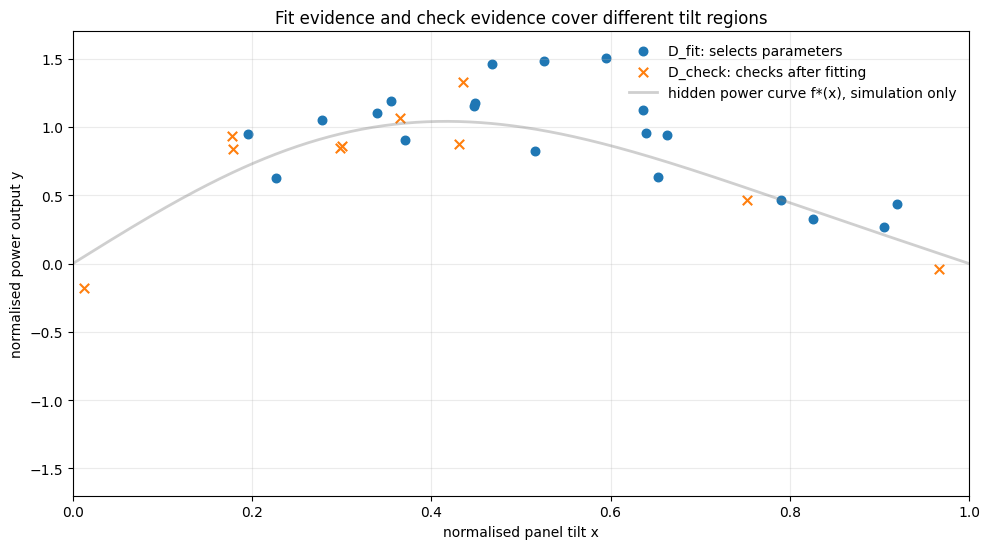

In [17]:
# Inspect which tilt regions fit the rule and which regions check it.
x_grid = data.make_test_grid(n_points=500)
fig, ax = plt.subplots(figsize=(10.0, 5.6))
ax.scatter(x_fit, y_fit, s=38, color="#1f77b4", label="D_fit: selects parameters")
ax.scatter(x_check, y_check, s=46, color="#ff7f0e", marker="x", label="D_check: checks after fitting")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x), simulation only")
ax.set_title("Fit evidence and check evidence cover different tilt regions")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("normalised power output y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.7, 1.7)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
show_fig(fig)

### 2.1 Before running: predict fit/check behaviour

The next cells fit several polynomial degrees. This changes the hypothesis space $\mathcal{H}$ while keeping the fitting rule $\mathcal{O}$ and the split fixed.

Before running, predict:

1. Which degree will have the lowest fit MSE?
2. Which degree will have the lowest check MSE?
3. Which degree will look least defensible away from measured panel tilts?

Watch for the first generalisation pattern: fit error can improve while held-out check error gets worse. In that case, the selected rule is specialising to the evidence that selected it.


In [18]:
# Fit candidate hypothesis spaces and score fit/check evidence separately.
degrees_to_score = (0, 1, 3, 5, 9)
score_grid = data.make_test_grid(n_points=500)
score_rows = []
score_fits = {}
score_coeffs = {}

for degree in degrees_to_score:
    coeffs = models.fit_polynomial_mle(x_fit, y_fit, degree=degree)
    fit_pred = models.predict_polynomial(x_fit, coeffs)
    check_pred = models.predict_polynomial(x_check, coeffs)
    score_coeffs[degree] = coeffs
    score_fits[degree] = models.predict_polynomial(score_grid, coeffs)
    score_rows.append(
        {
            "degree": degree,
            "n_features": degree + 1,
            "fit_mse": metrics.mse(y_fit, fit_pred),
            "check_mse": metrics.mse(y_check, check_pred),
            "coef_norm_warning": metrics.coefficient_norm(coeffs),
        }
    )

best_fit = min(score_rows, key=lambda row: row["fit_mse"])
best_check = min(score_rows, key=lambda row: row["check_mse"])

print_rows(score_rows, digits=4, title="Fit/check error by polynomial degree")
print_rows(
    [
        {"criterion": "lowest_fit_mse", **best_fit},
        {"criterion": "lowest_check_mse", **best_check},
    ],
    digits=4,
    title="Fit and check evidence can favour different degrees",
)

Fit/check error by polynomial degree
01. degree=0, n_features=1, fit_mse=0.1321, check_mse=0.2583, coef_norm_warning=0.9280
02. degree=1, n_features=2, fit_mse=0.0953, check_mse=0.3508, coef_norm_warning=1.6875
03. degree=3, n_features=4, fit_mse=0.0438, check_mse=0.0603, coef_norm_warning=19.5088
04. degree=5, n_features=6, fit_mse=0.0350, check_mse=0.5581, coef_norm_warning=86.5834
05. degree=9, n_features=10, fit_mse=0.0283, check_mse=3116.0791, coef_norm_warning=1.17e+06
Fit and check evidence can favour different degrees
01. criterion=lowest_fit_mse, degree=9, n_features=10, fit_mse=0.0283, check_mse=3116.0791, coef_norm_warning=1.17e+06
02. criterion=lowest_check_mse, degree=3, n_features=4, fit_mse=0.0438, check_mse=0.0603, coef_norm_warning=19.5088


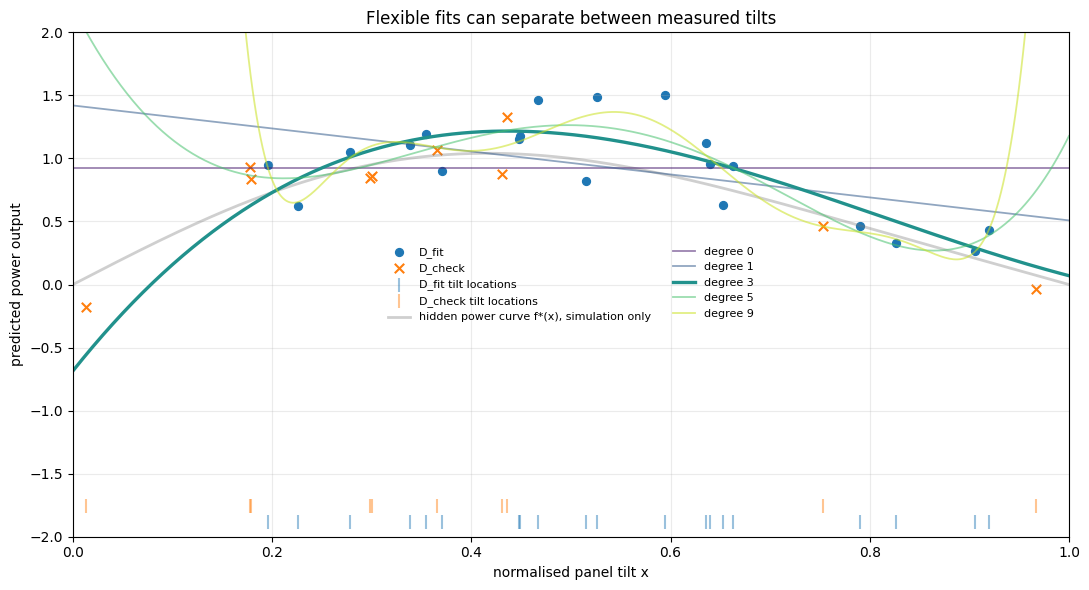

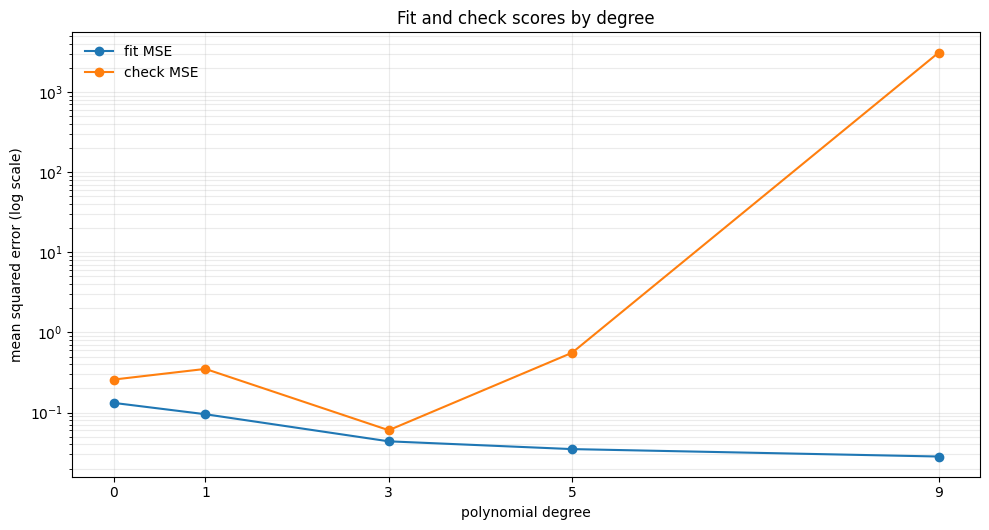

In [19]:
# Compare fitted functions with the fit/check score pattern.
degree_values = [row["degree"] for row in score_rows]
fit_mse_values = [row["fit_mse"] for row in score_rows]
check_mse_values = [row["check_mse"] for row in score_rows]

fig_curve, ax_curve = plt.subplots(figsize=(11.0, 6.0))
ax_curve.scatter(x_fit, y_fit, s=32, color="#1f77b4", label="D_fit")
ax_curve.scatter(x_check, y_check, s=46, color="#ff7f0e", marker="x", label="D_check")
ax_curve.scatter(x_fit, np.full_like(x_fit, -1.88), marker="|", s=90, color="#1f77b4", alpha=0.45, label="D_fit tilt locations")
ax_curve.scatter(x_check, np.full_like(x_check, -1.76), marker="|", s=90, color="#ff7f0e", alpha=0.45, label="D_check tilt locations")
ax_curve.plot(score_grid, data.true_function(score_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x), simulation only")
colors = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(degrees_to_score)))
for color, degree in zip(colors, degrees_to_score):
    linewidth = 2.4 if degree == best_check["degree"] else 1.3
    alpha = 1.0 if degree == best_check["degree"] else 0.55
    ax_curve.plot(score_grid, score_fits[degree], color=color, linewidth=linewidth, alpha=alpha, label=f"degree {degree}")
ax_curve.set_title("Flexible fits can separate between measured tilts")
ax_curve.set_xlabel("normalised panel tilt x")
ax_curve.set_ylabel("predicted power output")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-2.0, 2.0)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=8, ncol=2)
fig_curve.tight_layout()
show_fig(fig_curve)

fig_score, ax_score = plt.subplots(figsize=(10.0, 5.4))
ax_score.plot(degree_values, fit_mse_values, marker="o", label="fit MSE")
ax_score.plot(degree_values, check_mse_values, marker="o", label="check MSE")
ax_score.set_yscale("log")
ax_score.set_title("Fit and check scores by degree")
ax_score.set_xlabel("polynomial degree")
ax_score.set_ylabel("mean squared error (log scale)")
ax_score.set_xticks(degree_values)
ax_score.grid(alpha=0.25, which="both")
ax_score.legend(frameon=False)
fig_score.tight_layout()
show_fig(fig_score)

### 2.2 After running: diagnose fit/check evidence

Read the table and plots as an evaluation diagnostic.

- High fit error and high check error point to a hypothesis space that may be too limited for the pattern.
- Low fit error with worsening check error points to a hypothesis space flexible enough to specialise to $\mathcal{D}_{fit}$.
- Low average check error with a visibly weak region points to a local failure hidden by the global score.

This section changed $\mathcal{H}$ while holding the split and fitting rule fixed. The next section changes the evidence roles used for model refinement.


<br>

## 3. Validation, Test, and the Settled Workflow

Validation evidence guides modelling choices. Test evidence checks the workflow after those choices have stopped moving.

Use three evidence roles while modelling choices are still open:

| Evidence role | What it is allowed to do |
|---|---|
| Training evidence | Fit parameters for a fixed modelling choice. |
| Validation evidence | Choose modelling settings such as degree, regularisation, preprocessing, prompts, or features. |
| Test evidence | Check the settled workflow once after choices are fixed. |

Once held-out evidence guides degree or preprocessing, treat it as validation evidence. Keep a separate test set for the workflow you are prepared to defend without further tuning on that same test result.


### 3.1 Before running: decide what validation may change

The next cells use training evidence to fit coefficients and validation evidence to choose polynomial degree. The test evidence is created now and kept hidden until the validation-based choice is fixed.

Before running, write down validation's authority. In this notebook validation may choose polynomial degree. Hold the data generator, cleaning choices, and test set fixed.


In [20]:
# Build train/validation/test roles for a model-choice workflow.
workflow_n_samples = 36
workflow_noise_std = 0.20
workflow_seed = 2026
workflow_sampling = "uniform"
workflow_degrees = (0, 1, 3, 5, 9, 15)

x_workflow, y_workflow = data.make_regression_data(
    n=workflow_n_samples,
    noise_std=workflow_noise_std,
    seed=workflow_seed,
    sampling=workflow_sampling,
)
x_build, y_build, x_test_final, y_test_final = data.train_test_split_for_workshop(
    x_workflow,
    y_workflow,
    test_size=0.25,
    seed=workflow_seed + 1,
)
x_train_model, y_train_model, x_val_model, y_val_model = data.train_test_split_for_workshop(
    x_build,
    y_build,
    test_size=0.33,
    seed=workflow_seed + 2,
)

print_rows(
    [
        {"role": "train", "n": len(x_train_model), "x_min": np.min(x_train_model), "x_max": np.max(x_train_model)},
        {"role": "validation", "n": len(x_val_model), "x_min": np.min(x_val_model), "x_max": np.max(x_val_model)},
        {"role": "test_hidden_until_final", "n": len(x_test_final), "x_min": np.min(x_test_final), "x_max": np.max(x_test_final)},
    ],
    title="Train, validation, and test roles",
)

Train, validation, and test roles
01. role=train, n=18, x_min=0.1789, x_max=0.8259
02. role=validation, n=9, x_min=0.1774, x_max=0.9051
03. role=test_hidden_until_final, n=9, x_min=0.0128, x_max=0.9670


In [21]:
# Fit each candidate degree on training evidence and choose degree using validation evidence.
workflow_grid = data.make_test_grid(n_points=500)
workflow_rows = []
workflow_fits = {}
workflow_coeffs = {}

for degree in workflow_degrees:
    coeffs = models.fit_polynomial_mle(x_train_model, y_train_model, degree=degree)
    train_pred = models.predict_polynomial(x_train_model, coeffs)
    val_pred = models.predict_polynomial(x_val_model, coeffs)
    workflow_coeffs[degree] = coeffs
    workflow_fits[degree] = models.predict_polynomial(workflow_grid, coeffs)
    workflow_rows.append(
        {
            "degree": degree,
            "train_mse": metrics.mse(y_train_model, train_pred),
            "validation_mse": metrics.mse(y_val_model, val_pred),
            "coef_norm_warning": metrics.coefficient_norm(coeffs),
        }
    )

best_validation = min(workflow_rows, key=lambda row: row["validation_mse"])
selected_degree = int(best_validation["degree"])

print_rows(workflow_rows, digits=4, title="Train and validation scores by degree")
print_rows([{"criterion": "lowest_validation_mse", **best_validation}], digits=4, title="Degree selected by validation evidence")
print(f"Current selected_degree is {selected_degree}. Keep this fixed before the test check unless your validation argument already chose a different degree.")

Train and validation scores by degree
01. degree=0, train_mse=0.2008, validation_mse=0.1213, coef_norm_warning=0.8688
02. degree=1, train_mse=0.1365, validation_mse=0.1057, coef_norm_warning=1.8946
03. degree=3, train_mse=0.0243, validation_mse=0.0491, coef_norm_warning=45.6689
04. degree=5, train_mse=0.0238, validation_mse=0.0503, coef_norm_warning=425.9456
05. degree=9, train_mse=0.0163, validation_mse=41.4206, coef_norm_warning=7.12e+06
06. degree=15, train_mse=0.0036, validation_mse=2.49e+04, coef_norm_warning=1.51e+11
Degree selected by validation evidence
01. criterion=lowest_validation_mse, degree=3, train_mse=0.0243, validation_mse=0.0491, coef_norm_warning=45.6689
Current selected_degree is 3. Keep this fixed before the test check unless your validation argument already chose a different degree.


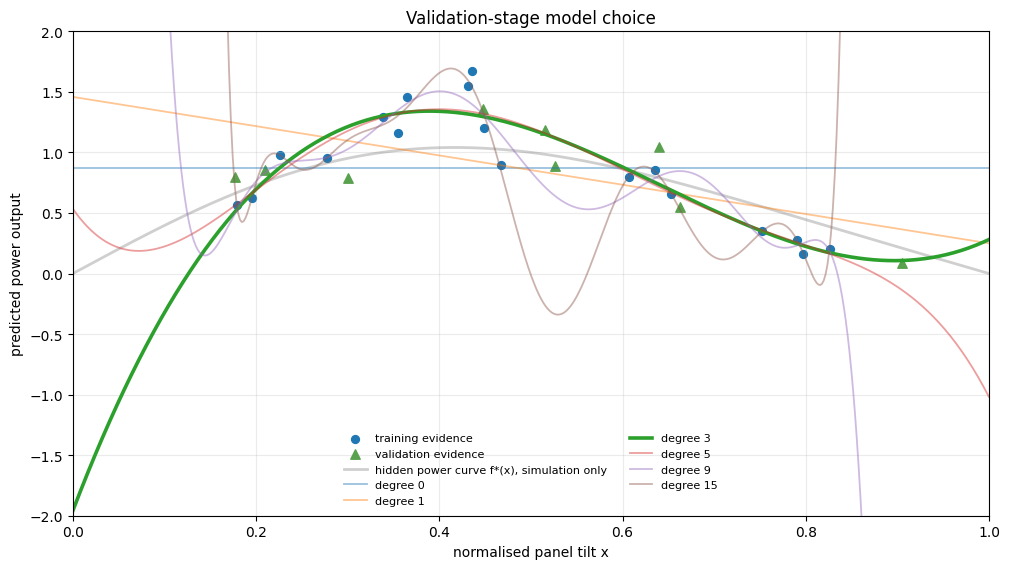

In [22]:
# Visualise the validation-stage choice while test evidence stays hidden.
fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_model, y_train_model, s=32, color="#1f77b4", label="training evidence")
ax.scatter(x_val_model, y_val_model, s=46, marker="^", color="#59a14f", label="validation evidence")
ax.plot(workflow_grid, data.true_function(workflow_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x), simulation only")
for degree in workflow_degrees:
    linewidth = 2.6 if degree == selected_degree else 1.3
    alpha = 1.0 if degree == selected_degree else 0.45
    ax.plot(workflow_grid, workflow_fits[degree], linewidth=linewidth, alpha=alpha, label=f"degree {degree}")
ax.set_title("Validation-stage model choice")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("predicted power output")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
show_fig(fig)

### 3.2 Commit before the test check

The validation table has selected a degree. Before looking at the test score, write down the selected degree and the validation argument that supports it.

The test set then checks one settled workflow: the training split, validation rule, selected degree, fitted coefficients, and plotting/score protocol already used above. A change after seeing the test result turns this test evidence into validation evidence and calls for a new untouched test check.


### 3.3 Final test check

Run the next cell after the validation-based model choice is fixed. Read the test MSE as evidence for this settled workflow.


Test check for the settled workflow
01. selected_degree=3, train_mse=0.0243, validation_mse=0.0491, test_mse_final_check=0.3541


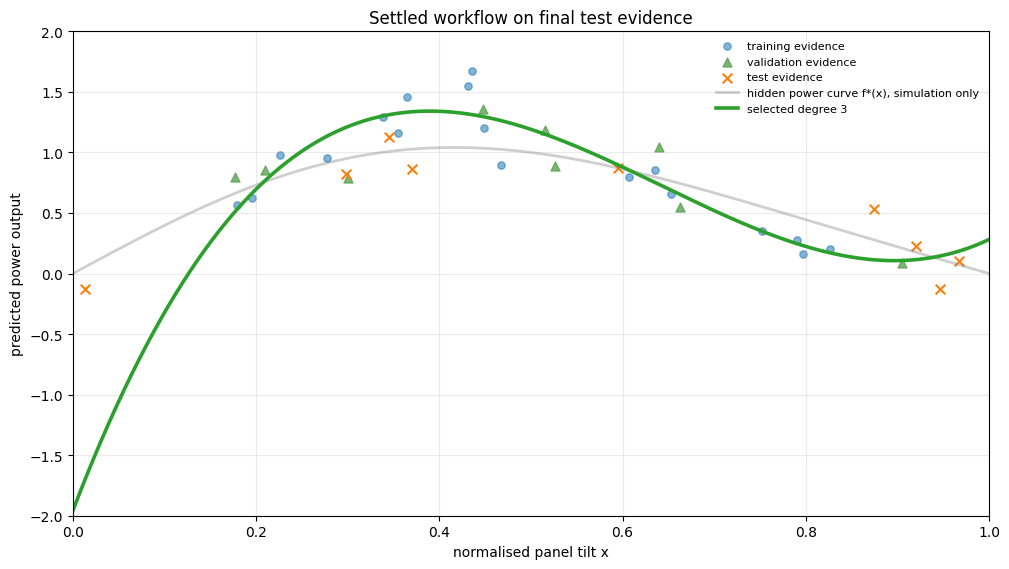

In [23]:
# Check the settled validation-selected workflow on test evidence.
selected_test_pred = models.predict_polynomial(x_test_final, workflow_coeffs[selected_degree])
selected_test_mse = metrics.mse(y_test_final, selected_test_pred)
selected_validation_mse = next(row["validation_mse"] for row in workflow_rows if row["degree"] == selected_degree)
selected_train_mse = next(row["train_mse"] for row in workflow_rows if row["degree"] == selected_degree)

print_rows(
    [
        {
            "selected_degree": selected_degree,
            "train_mse": selected_train_mse,
            "validation_mse": selected_validation_mse,
            "test_mse_final_check": selected_test_mse,
        }
    ],
    digits=4,
    title="Test check for the settled workflow",
)

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_model, y_train_model, s=28, color="#1f77b4", alpha=0.55, label="training evidence")
ax.scatter(x_val_model, y_val_model, s=42, marker="^", color="#59a14f", alpha=0.78, label="validation evidence")
ax.scatter(x_test_final, y_test_final, s=48, marker="x", color="#ff7f0e", label="test evidence")
ax.plot(workflow_grid, data.true_function(workflow_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x), simulation only")
ax.plot(workflow_grid, workflow_fits[selected_degree], color="#2ca02c", linewidth=2.6, label=f"selected degree {selected_degree}")
ax.set_title("Settled workflow on final test evidence")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("predicted power output")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
show_fig(fig)

<br>

## 4. Split Policy Controls the Claim

How evidence is held out decides the question the score answers.

A random split fits same-source future cases: new readings drawn like independent samples from the same process. For dependent, repeated, duplicated, grouped, time-ordered, or regime-specific rows, hold out the relevant structure so the check matches the harder deployment question.

A structured split asks a transfer question: does the selected rule work for a held-out time period, site, group, document source, operating condition, or input region?

Choose the split policy that matches the claim. The same fitted rule can support a same-source claim and still fail a transfer claim.


### 4.1 Before running: choose the claim first

The next cell fits the same polynomial degree under two split policies:

- a random same-source check;
- a structured right-tilt check.

Before running, decide which claim each split can support. The random split asks about average same-source performance. The structured split asks whether the model transfers to a panel-tilt region that was unavailable during fitting.


Same model under two split policies
01. policy=random same-source check, degree=3, train_x_max=0.9703, heldout_x_min=0.1596, train_mse=0.0211, heldout_mse=0.0209
02. policy=structured right-tilt check, degree=3, train_x_max=0.6217, heldout_x_min=0.6610, train_mse=0.0212, heldout_mse=0.2102


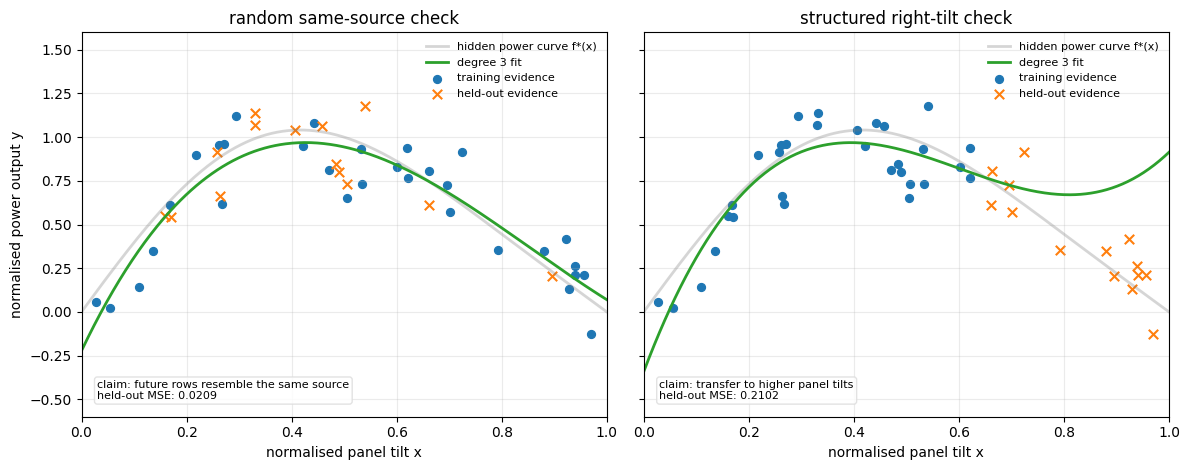

In [24]:
# Compare random and structured split policies on the same solar-panel observations.
split_policy_seed = 2042
split_policy_degree = 3
x_policy, y_policy = data.make_regression_data(
    n=45,
    noise_std=0.18,
    seed=split_policy_seed,
    sampling="uniform",
)
x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)

rng = np.random.default_rng(split_policy_seed)
heldout_count = int(round(0.30 * len(x_policy)))
random_heldout = np.zeros(len(x_policy), dtype=bool)
random_heldout[rng.permutation(len(x_policy))[:heldout_count]] = True

structured_cutoff = np.quantile(x_policy, 0.70)
structured_heldout = x_policy >= structured_cutoff

split_policies = [
    {
        "label": "random same-source check",
        "claim": "future rows resemble the same source",
        "heldout_mask": random_heldout,
    },
    {
        "label": "structured right-tilt check",
        "claim": "transfer to higher panel tilts",
        "heldout_mask": structured_heldout,
    },
]

policy_rows = []
policy_results = []

for policy in split_policies:
    heldout_mask = policy["heldout_mask"]
    train_mask = ~heldout_mask
    coeffs = models.fit_polynomial_mle(x_policy[train_mask], y_policy[train_mask], degree=split_policy_degree)
    train_pred = models.predict_polynomial(x_policy[train_mask], coeffs)
    heldout_pred = models.predict_polynomial(x_policy[heldout_mask], coeffs)
    grid_pred = models.predict_polynomial(x_grid, coeffs)
    policy_rows.append(
        {
            "policy": policy["label"],
            "degree": split_policy_degree,
            "train_x_max": np.max(x_policy[train_mask]),
            "heldout_x_min": np.min(x_policy[heldout_mask]),
            "train_mse": metrics.mse(y_policy[train_mask], train_pred),
            "heldout_mse": metrics.mse(y_policy[heldout_mask], heldout_pred),
        }
    )
    policy_results.append(
        {
            **policy,
            "train_mask": train_mask,
            "grid_pred": grid_pred,
        }
    )

print_rows(policy_rows, digits=4, title="Same model under two split policies")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharey=True)
for ax, result, row in zip(axes, policy_results, policy_rows):
    train_mask = result["train_mask"]
    heldout_mask = result["heldout_mask"]
    ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.30, linewidth=2.0, label="hidden power curve f*(x)")
    ax.plot(x_grid, result["grid_pred"], color="#2ca02c", linewidth=2.0, label=f"degree {split_policy_degree} fit")
    ax.scatter(x_policy[train_mask], y_policy[train_mask], s=32, color="#1f77b4", label="training evidence")
    ax.scatter(x_policy[heldout_mask], y_policy[heldout_mask], s=46, marker="x", color="#ff7f0e", label="held-out evidence")
    ax.set_title(result["label"])
    ax.text(
        0.03,
        0.04,
        f"claim: {result['claim']}\nheld-out MSE: {format_value(row['heldout_mse'])}",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom",
        ha="left",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.84, "edgecolor": "#dddddd"},
    )
    ax.set_xlabel("normalised panel tilt x")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.6, 1.6)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("normalised power output y")
fig.tight_layout()
show_fig(fig)

### 4.2 After running: diagnose the split policy

The same fitted model can look acceptable under one split and weak under another because the splits ask different questions.

Use this rule of thumb:

- For independent same-source deployment, begin with a random split.
- For dependent, repeated, or grouped rows, split by the dependency unit before trusting the score.
- For deployment to a region, time period, subgroup, or operating condition, hold out that structure.

A score becomes interpretable after the split policy has been matched to the claim.


<br>

## 5. Global Scores and Local Support

Average held-out MSE compresses several regimes into one number. Deployment often needs a local reading:

> Where is the fitted rule supported by nearby evidence, and where is it travelling on model assumptions?

This notebook uses four simple regimes:

- **supported interpolation:** inside the observed training range with nearby training points;
- **gap interpolation:** inside the observed training range but far from nearby training points;
- **extrapolation:** outside the observed training range;
- **deployment region $\Omega$:** the region where we plan to use the rule.

Use these regimes as trust labels. They mark where the evidence is doing more work and where assumptions are doing more work.


### 5.1 Before running: predict where flexibility will matter most

The next cells compare degree 3 and degree 9 under two evidence patterns:

- clustered evidence with an internal gap;
- partial-domain evidence where high tilts require extrapolation.

Before running, predict which region should be most sensitive to the hypothesis space: supported interpolation, an internal gap, or extrapolation.


In [25]:
# Evaluate fitted rules by local evidence regime.
local_degrees = [3, 9]
local_noise_std = 0.20
local_seed = 2026
deployment_tilt_region = (0.60, 0.90)
support_radius = 0.06

x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)
region_min, region_max = deployment_tilt_region
deployment_mask = (x_grid >= region_min) & (x_grid <= region_max)

local_cases = [
    {"case": "clustered evidence with an internal gap", "sampling": "clustered"},
    {"case": "partial-domain evidence with high-tilt extrapolation", "sampling": "partial_domain"},
]

local_results = []
support_rows = []
local_rows = []


def fmt_metric(value):
    if value is None or np.isnan(value):
        return "n/a"
    return format_value(float(value), digits=4)


def region_mse(mask, prediction):
    if not np.any(mask):
        return np.nan
    return metrics.mse(y_grid_true[mask], prediction[mask])


for settings in local_cases:
    x_local, y_local = data.make_regression_data(
        n=26,
        noise_std=local_noise_std,
        seed=local_seed,
        sampling=settings["sampling"],
    )

    nearest_distance = np.min(np.abs(x_grid[:, None] - x_local[None, :]), axis=1)
    inside_observed_range = (x_grid >= np.min(x_local)) & (x_grid <= np.max(x_local))
    outside_observed_range = ~inside_observed_range

    internal_gaps = np.diff(x_local)
    gap_index = int(np.argmax(internal_gaps))
    gap_min = float(x_local[gap_index])
    gap_max = float(x_local[gap_index + 1])
    gap_mask = inside_observed_range & (x_grid >= gap_min) & (x_grid <= gap_max)
    supported_mask = inside_observed_range & (nearest_distance <= support_radius) & ~gap_mask

    deployment_nearest = nearest_distance[deployment_mask]
    support_rows.append(
        {
            "case": settings["case"],
            "x_min": np.min(x_local),
            "x_max": np.max(x_local),
            "largest_internal_gap": np.max(internal_gaps),
            "deployment_max_nearest": np.max(deployment_nearest),
            "deployment_extrap_fraction": np.mean(outside_observed_range[deployment_mask]),
        }
    )

    for degree in local_degrees:
        coeffs = models.fit_polynomial_mle(x_local, y_local, degree=degree)
        train_pred = models.predict_polynomial(x_local, coeffs)
        grid_pred = models.predict_polynomial(x_grid, coeffs)
        region_metrics = {
            "global_oracle_mse": metrics.mse(y_grid_true, grid_pred),
            "supported_mse": region_mse(supported_mask, grid_pred),
            "gap_mse": region_mse(gap_mask, grid_pred),
            "extrapolation_mse": region_mse(outside_observed_range, grid_pred),
            "deployment_mse": region_mse(deployment_mask, grid_pred),
        }
        local_rows.append(
            {
                "case": settings["case"],
                "degree": degree,
                "train_mse": metrics.mse(y_local, train_pred),
                **region_metrics,
                "coef_norm_warning": metrics.coefficient_norm(coeffs),
            }
        )
        local_results.append(
            {
                "case": settings["case"],
                "degree": degree,
                "x": x_local,
                "y": y_local,
                "grid_pred": grid_pred,
                "train_mse": metrics.mse(y_local, train_pred),
                "region_metrics": region_metrics,
                "gap_mask": gap_mask,
                "outside_observed_range": outside_observed_range,
            }
        )

print_rows(support_rows, digits=4, title="Evidence support by data pattern")
print_rows(local_rows, digits=4, title="Global and local errors by regime")

Evidence support by data pattern
01. case=clustered evidence with an internal gap, x_min=0.1073, x_max=0.8677, largest_internal_gap=0.3061, deployment_max_nearest=0.0426, deployment_extrap_fraction=0.1133
02. case=partial-domain evidence with high-tilt extrapolation, x_min=0.0090, x_max=0.6769, largest_internal_gap=0.1152, deployment_max_nearest=0.2229, deployment_extrap_fraction=0.7467
Global and local errors by regime
01. case=clustered evidence with an internal gap, degree=3, train_mse=0.0428, global_oracle_mse=0.0607, supported_mse=0.0252, gap_mse=0.0008, extrapolation_mse=0.2026, deployment_mse=0.0588, coef_norm_warning=17.8977
02. case=clustered evidence with an internal gap, degree=9, train_mse=0.0304, global_oracle_mse=99.4295, supported_mse=0.0700, gap_mse=0.2099, extrapolation_mse=410.4695, deployment_mse=0.0965, coef_norm_warning=2.47e+06
03. case=partial-domain evidence with high-tilt extrapolation, degree=3, train_mse=0.0381, global_oracle_mse=0.1605, supported_mse=0.0288,

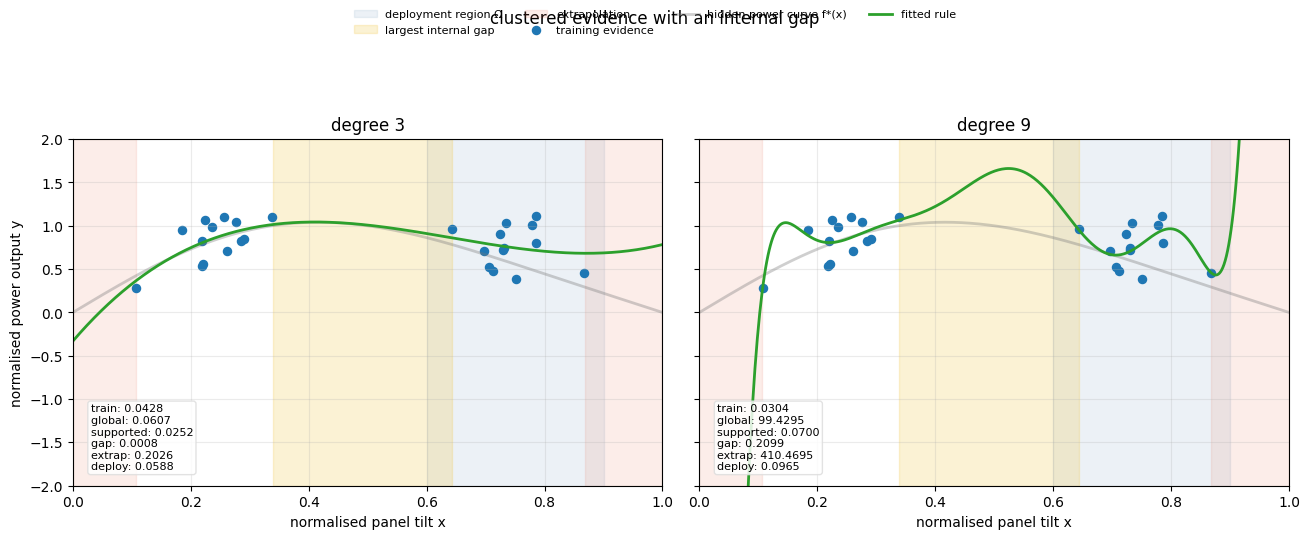

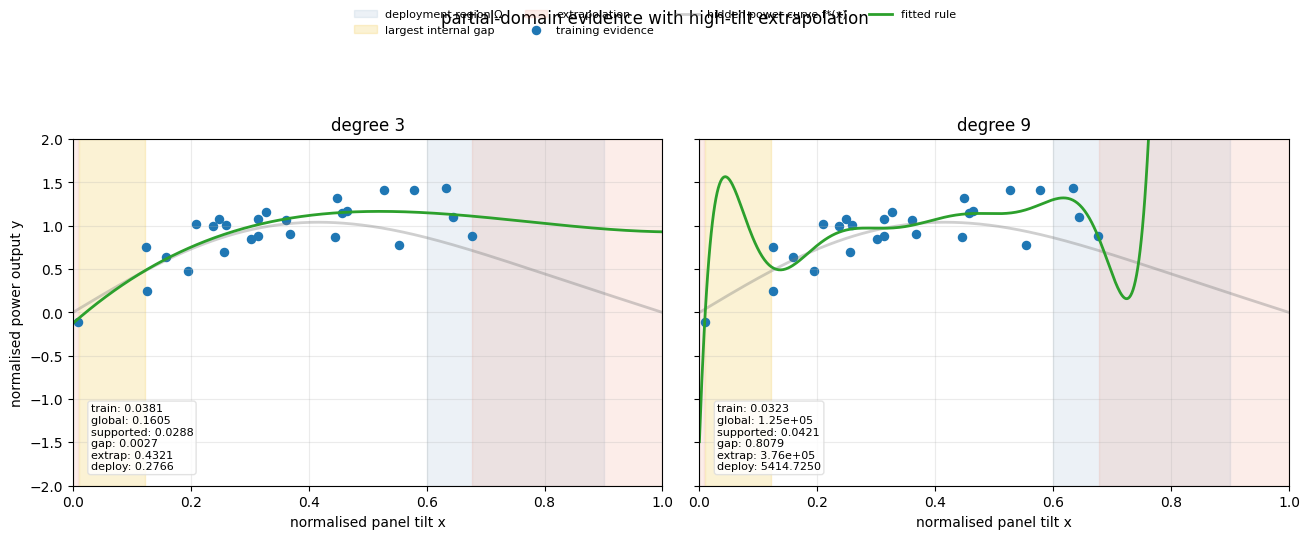

In [26]:
# Visualise local failure modes by data pattern and hypothesis-space choice.
for settings in local_cases:
    case_results = [result for result in local_results if result["case"] == settings["case"]]
    fig, axes = plt.subplots(1, len(case_results), figsize=(13.2, 5.4), sharex=True, sharey=True)
    if len(case_results) == 1:
        axes = [axes]

    for ax, result in zip(axes, case_results):
        ax.axvspan(region_min, region_max, color="#4e79a7", alpha=0.10, label="deployment region Ω")
        if np.any(result["gap_mask"]):
            gap_x = x_grid[result["gap_mask"]]
            ax.axvspan(gap_x.min(), gap_x.max(), color="#f2c94c", alpha=0.24, label="largest internal gap")
        if np.any(result["outside_observed_range"]):
            outside_x = x_grid[result["outside_observed_range"]]
            if outside_x.min() < result["x"].min():
                left_x = outside_x[outside_x < result["x"].min()]
                ax.axvspan(left_x.min(), left_x.max(), color="#e76f51", alpha=0.12, label="extrapolation")
            if outside_x.max() > result["x"].max():
                right_x = outside_x[outside_x > result["x"].max()]
                ax.axvspan(right_x.min(), right_x.max(), color="#e76f51", alpha=0.12, label="extrapolation")

        ax.scatter(result["x"], result["y"], s=34, color="#1f77b4", label="training evidence")
        ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
        ax.plot(x_grid, result["grid_pred"], color="#2ca02c", linewidth=2.0, label="fitted rule")

        region_metrics = result["region_metrics"]
        metric_text = "\n".join(
            [
                f"train: {fmt_metric(result['train_mse'])}",
                f"global: {fmt_metric(region_metrics['global_oracle_mse'])}",
                f"supported: {fmt_metric(region_metrics['supported_mse'])}",
                f"gap: {fmt_metric(region_metrics['gap_mse'])}",
                f"extrap: {fmt_metric(region_metrics['extrapolation_mse'])}",
                f"deploy: {fmt_metric(region_metrics['deployment_mse'])}",
            ]
        )
        ax.text(
            0.03,
            0.04,
            metric_text,
            transform=ax.transAxes,
            fontsize=8,
            va="bottom",
            ha="left",
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.84, "edgecolor": "#dddddd"},
        )
        ax.set_title(f"degree {result['degree']}")
        ax.set_xlabel("normalised panel tilt x")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-2.0, 2.0)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("normalised power output y")
    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=4, frameon=False, fontsize=8)
    fig.suptitle(settings["case"], y=0.99)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.88))
    show_fig(fig)

### 5.2 After running: diagnose local failure modes

Read the local table differently from a single global score.

- Low training error with high extrapolation error points to weak support outside the observed data range.
- High gap error points to weak data support inside the observed range.
- High deployment-region error matters even when the global average looks acceptable.
- A large degree-3 versus degree-9 difference in weak regions means $\mathcal{H}$ is deciding behaviour that $\mathcal{D}$ left underconstrained.

This local diagnosis prepares the next step: choosing which part of the learning frame should change.


<br>

## 6. Use Failures to Choose the Next Lever

Evaluation should guide the next modelling decision. Use the failure pattern to choose a lever before changing model size.

| Failure pattern | Likely response |
|---|---|
| Too simple across the domain | Change $\mathcal{H}$ or features. |
| Good fit, poor check score | Reduce flexibility, regularise, or collect stronger check evidence. |
| Weak gap or deployment region | Change $\mathcal{D}$ by collecting targeted evidence. |
| Weak extrapolation | Narrow $\Omega$, collect data there, or add stronger modelling assumptions. |
| Split mismatch | Change the split policy before trusting the score. |

The next intervention keeps $\mathcal{H}$ and $\mathcal{O}$ fixed while changing $\mathcal{D}$. This isolates the data-space lever.


### 6.1 Before running: predict the data-space intervention

The next cells use the same degree and fitting rule while changing the evidence pattern.

Predict which case will be most fragile in the deployment region and why:

| Data intervention | Expected effect on support | Expected effect on deployment error | Why? |
|---|---|---|---|
| Uniform data | | | |
| More uniform data | | | |
| Clustered data | | | |
| Higher noise | | | |
| Partial domain | | | |


In [27]:
# Keep the fitting rule and hypothesis space fixed while changing data space.
intervention_degree = 9
intervention_seed = 2026
interventions = [
    {"label": "uniform", "n": 20, "noise": 0.20, "sampling": "uniform"},
    {"label": "more data", "n": 80, "noise": 0.20, "sampling": "uniform"},
    {"label": "clustered", "n": 20, "noise": 0.20, "sampling": "clustered"},
    {"label": "higher noise", "n": 20, "noise": 0.45, "sampling": "uniform"},
    {"label": "partial domain", "n": 20, "noise": 0.20, "sampling": "partial_domain"},
]

x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)
deployment_mask = (x_grid >= region_min) & (x_grid <= region_max)
intervention_results = []
intervention_rows = []

for settings in interventions:
    x_int, y_int = data.make_regression_data(
        n=settings["n"],
        noise_std=settings["noise"],
        seed=intervention_seed,
        sampling=settings["sampling"],
    )
    coeffs = models.fit_polynomial_mle(x_int, y_int, degree=intervention_degree)
    train_pred = models.predict_polynomial(x_int, coeffs)
    grid_pred = models.predict_polynomial(x_grid, coeffs)
    nearest_distance = np.min(np.abs(x_grid[:, None] - x_int[None, :]), axis=1)

    intervention_results.append(
        {
            "settings": settings,
            "x": x_int,
            "y": y_int,
            "grid_pred": grid_pred,
        }
    )
    intervention_rows.append(
        {
            "case": settings["label"],
            "n": settings["n"],
            "noise": settings["noise"],
            "x_min": np.min(x_int),
            "x_max": np.max(x_int),
            "deploy_max_nearest": np.max(nearest_distance[deployment_mask]),
            "train_mse": metrics.mse(y_int, train_pred),
            "oracle_grid_mse": metrics.mse(y_grid_true, grid_pred),
            "oracle_deploy_mse": metrics.mse(y_grid_true[deployment_mask], grid_pred[deployment_mask]),
            "coef_norm_warning": metrics.coefficient_norm(coeffs),
        }
    )

print_rows(intervention_rows, digits=4, title="Changing D with H and O fixed")

Changing D with H and O fixed
01. case=uniform, n=20, noise=0.2000, x_min=0.1774, x_max=0.9670, deploy_max_nearest=0.0493, train_mse=0.0171, oracle_grid_mse=181.4153, oracle_deploy_mse=0.0133, coef_norm_warning=1.68e+06
02. case=more data, n=80, noise=0.2000, x_min=0.0018, x_max=0.9897, deploy_max_nearest=0.0238, train_mse=0.0429, oracle_grid_mse=0.0030, oracle_deploy_mse=0.0017, coef_norm_warning=2.21e+04
03. case=clustered, n=20, noise=0.2000, x_min=0.1073, x_max=0.7904, deploy_max_nearest=0.1094, train_mse=0.0182, oracle_grid_mse=389.2473, oracle_deploy_mse=8.7568, coef_norm_warning=6.18e+06
04. case=higher noise, n=20, noise=0.4500, x_min=0.1774, x_max=0.9670, deploy_max_nearest=0.0493, train_mse=0.0867, oracle_grid_mse=918.4114, oracle_deploy_mse=0.0675, coef_norm_warning=3.78e+06
05. case=partial domain, n=20, noise=0.2000, x_min=0.1241, x_max=0.6769, deploy_max_nearest=0.2229, train_mse=0.0171, oracle_grid_mse=3.84e+06, oracle_deploy_mse=2.17e+05, coef_norm_warning=1.63e+07


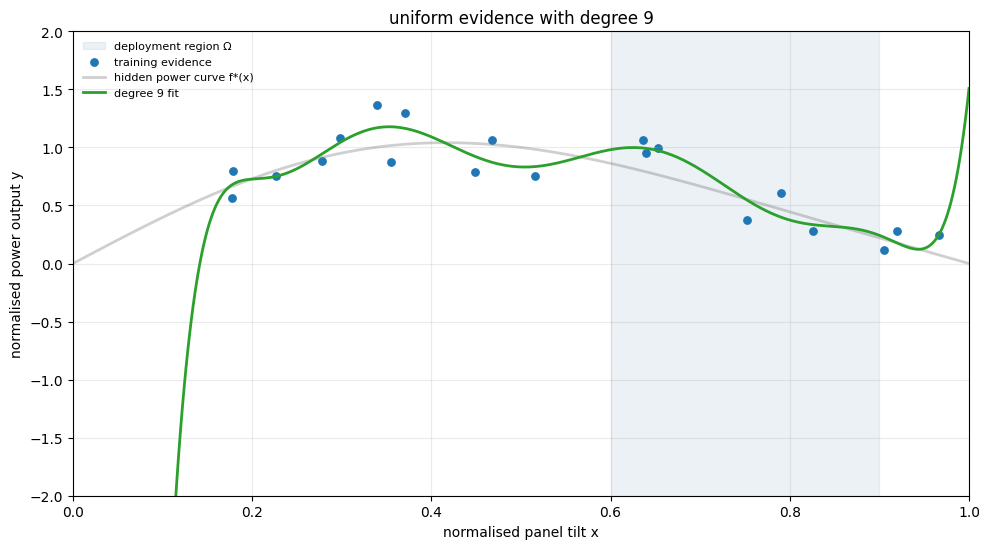

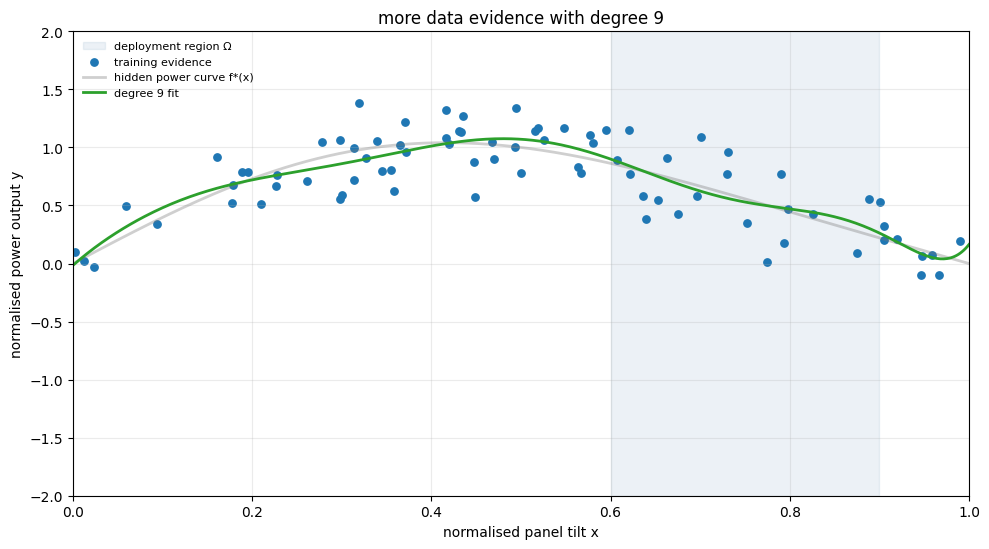

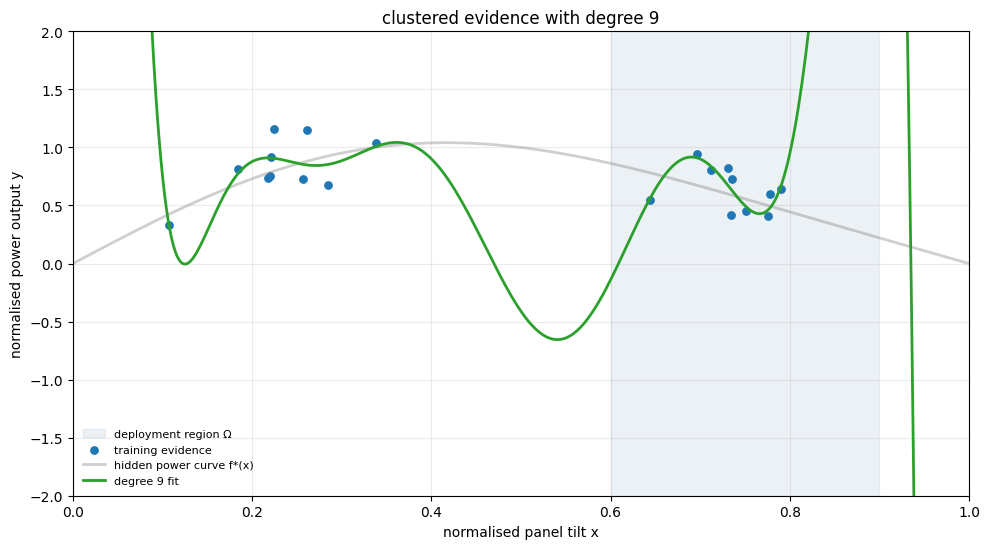

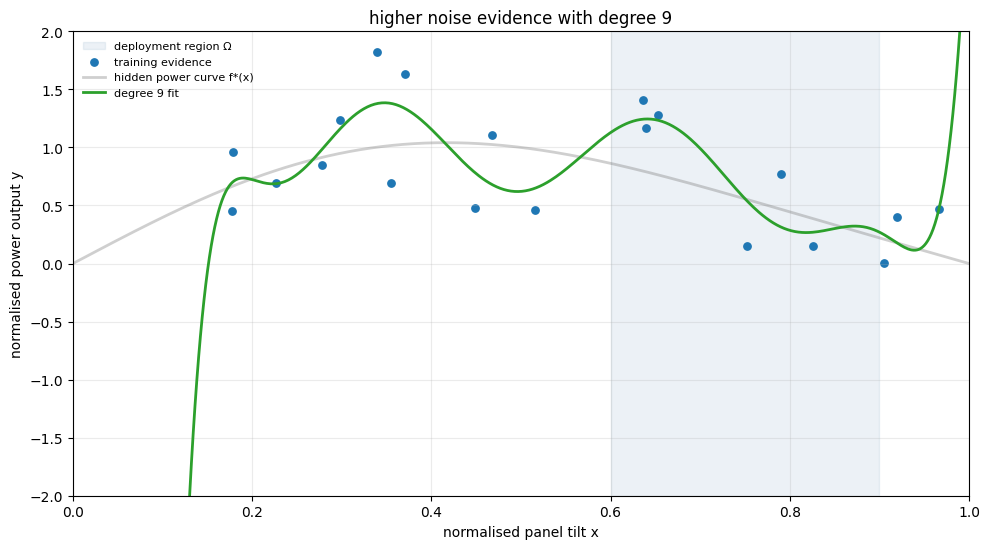

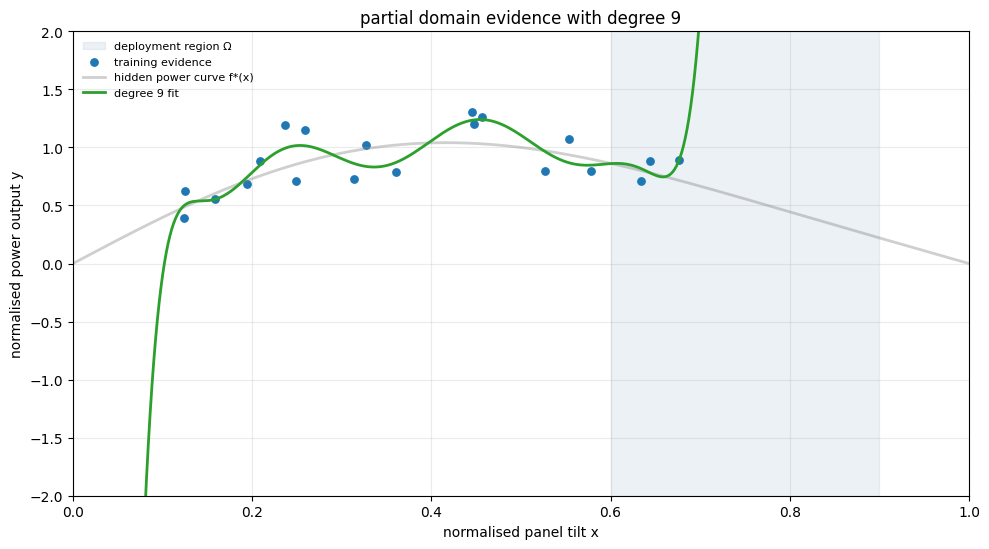

In [28]:
# Plot the same fitting rule under each data-space intervention.
for result in intervention_results:
    settings = result["settings"]
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.axvspan(region_min, region_max, color="#4e79a7", alpha=0.10, label="deployment region Ω")
    ax.scatter(result["x"], result["y"], s=28, color="#1f77b4", label="training evidence")
    ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
    ax.plot(x_grid, result["grid_pred"], color="#2ca02c", linewidth=2.0, label=f"degree {intervention_degree} fit")
    ax.set_title(f"{settings['label']} evidence with degree {intervention_degree}")
    ax.set_xlabel("normalised panel tilt x")
    ax.set_ylabel("normalised power output y")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)

### 6.2 After running: diagnose the intervention

This section kept the model class and optimizer fixed. When the fitted curve changed, the cause was evidence support.

Use the intervention results to choose the next action:

- More uniform data improving the deployment region points to a data-space coverage issue.
- Clustered data failing in gaps points to the value of observations in the missing region.
- Higher noise destabilising the fit points to repeated measurements or regularisation.
- Partial-domain data failing in the deployment region points to an extrapolation claim.

Evaluation now has a concrete use: it tells us what to change next.


<br>

## 7. Summary: Generalisation as an Evaluation Argument

Notebook 03 showed how the learning machinery selects a rule. This notebook asked where that selected rule can be trusted.

1. **Separate fitting from checking.** A rule fitted on one set of readings needs evidence it did not use.
2. **Use validation deliberately.** Validation evidence can refine degree, preprocessing, prompts, features, or regularisation.
3. **Use test evidence once the workflow is settled.** A test score supports the claim attached to the workflow already chosen.
4. **Match the split to the claim.** Random splits check same-source performance; structured splits check transfer across the held-out structure.
5. **Read scores locally.** Break evaluation into regimes that match deployment risk.
6. **Let failures choose the lever.** Change $\mathcal{D}$, $\mathcal{H}$, $\mathcal{O}$, or $\Omega$ based on the diagnosis.

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s
$$

Selection gives a model. Generalisation requires an evidence-based claim about where that model belongs in the acceptable solution space $\mathcal{S}$.


<br>

## 8. Generalisation Diagnostic Checklist

For any fitted model or AI workflow, ask:

| Question | Why it matters |
|---|---|
| What hypothesis space was available? | Names what the model could represent. |
| What evidence selected the parameters? | Names what shaped the fitted rule. |
| What optimization rule selected the solution? | Names the loss, penalty, and solver. |
| What validation evidence shaped modelling choices? | Names what guided refinement. |
| What test evidence remained untouched until the workflow was settled? | Names the final check. |
| What split policy was used? | Connects evaluation evidence to the intended claim. |
| Are samples independent, grouped, repeated, or structured? | Identifies leakage and too-easy checks. |
| Where is the deployment region $\Omega$? | Names where the model must be useful. |
| Which regions are supported interpolation, gaps, or extrapolation? | Names where evidence is strong or weak. |
| Which failure would change the modelling choice? | Turns evaluation into refinement. |

**Takeaway.** A defensible score comes with a claim: this settled workflow was checked on this evidence for this intended region of use.


<br>

## 9. Bridge to Notebook 05

Notebook 05 gives parts of this evaluation story a probabilistic interpretation.

A likelihood says what measurement story would make the residuals plausible. A prior says which parameters or functions were plausible before this dataset arrived. Posterior uncertainty gives another way to ask where the selected rule is well constrained and where it is travelling on assumptions.

The evaluation discipline remains the same: name the model, evidence roles, split policy, deployment region, and assumptions behind the trust claim.


<br>

## 10. References

These references support model assessment, validation, test evidence, split policy, and evaluation-driven data collection.

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). [*The Elements of Statistical Learning: Data Mining, Inference, and Prediction*](https://link.springer.com/book/10.1007/978-0-387-84858-7), 2nd ed. Model assessment, validation, test error, and model-complexity trade-offs.
- Stone, M. (1974). [*Cross-Validatory Choice and Assessment of Statistical Predictions*](https://academic.oup.com/jrsssb/article/36/2/111/7027414), *Journal of the Royal Statistical Society: Series B*, 36(2), 111-133. Classical support for held-out evidence in model choice and assessment.
- Settles, B. (2009). [*Active Learning Literature Survey*](https://minds.wisconsin.edu/handle/1793/60660), Computer Sciences Technical Report 1648, University of Wisconsin-Madison. Turning model diagnostics into targeted data-collection questions.
